# Logistic Regression — Complete Summary

**A comprehensive guide with intuitive analogies, mathematical rigor, and practical PyTorch implementation**

---

## Table of Contents

1. [The Problem: Binary Classification](#1-the-problem-binary-classification)
2. [Why Not Linear Regression?](#2-why-not-linear-regression)
3. [Step Function — The Failed Attempt](#3-step-function--the-failed-attempt)
4. [Sigmoid Function — The Squisher](#4-sigmoid-function--the-squisher)
5. [Geometric Interpretation](#5-geometric-interpretation)
6. [Log-Loss — Measuring Wrongness](#6-log-loss--measuring-wrongness)
7. [Likelihood vs Probability](#7-likelihood-vs-probability)
8. [Why Not MSE?](#8-why-not-mse)
9. [Gradient Descent — Finding the Best Weights](#9-gradient-descent--finding-the-best-weights)
10. [Complete Implementation](#10-complete-implementation)
11. [Regularization](#11-regularization)
12. [Interpreting Coefficients](#12-interpreting-coefficients)
13. [Quick Reference](#13-quick-reference)

---
## 1. The Problem: Binary Classification

**Use Case:** AT&T wants to predict which customers will churn (leave) vs stay.

**Key Insight:** This is a **yes/no decision**, not a continuous prediction.

**Notation:**
\[D = \{(x^{(i)}, y^{(i)})_{i=1}^m; \quad x^{(i)} \in \mathbb{R}^d; \quad y^{(i)} \in \{0,1\}\}\]

Where:
- \(m\) = number of data points (e.g., 5700 customers)
- \(d\) = number of features (e.g., 20 features like calls, charges)
- \(y^{(i)} \in \{0,1\}\) = label is **only** 0 or 1 (not continuous!)

---
## 2. Why Not Linear Regression?

Linear regression outputs any real number from \(-\infty\) to \(+\infty\).

**Problem:** What does a prediction of -0.3 or 1.7 mean for churn probability?

| Model | Output Range | Problem for Classification |
|:--|:--|:--|
| Linear Regression | \((-\infty, +\infty)\) | Negative probability? >100% probability? |
| Logistic Regression | \((0, 1)\) | Always valid probability ✓ |

**We need a "squisher" function** that compresses any input into the \((0, 1)\) range.

---
## 3. Step Function — The Failed Attempt

**Idea:** Just threshold!
\[
\text{step}(z) = 
\begin{cases} 
1 & \text{if } z \geq 0 \\
0 & \text{if } z < 0
\end{cases}
\]

**Fatal Flaw:** Not differentiable → can't use gradient descent!

> 🏔️ **The Blindfolded Hiker Analogy:**
> 
> Gradient descent is like a blindfolded hiker feeling the slope to find the valley.
> - Step function is **flat everywhere** except at one point (cliff)
> - Hiker feels "flat" and doesn't know which way to go
> - **Stuck!**

---
## 4. Sigmoid Function — The Squisher

**The Formula:**
\[
\sigma(z) = \frac{1}{1 + e^{-z}}
\]

**Properties:**
- Output range: \((0, 1)\) — always valid probability
- \(\sigma(0) = 0.5\) — uncertainty point
- Smooth and differentiable everywhere ✓

| Input \(z\) | Output \(\sigma(z)\) | Interpretation |
|:--:|:--:|:--|
| -100 | ≈ 0 | Almost certainly NO |
| -10 | 0.00005 | Very likely NO |
| 0 | 0.5 | Coin flip — uncertain |
| +10 | 0.99995 | Very likely YES |
| +100 | ≈ 1 | Almost certainly YES |

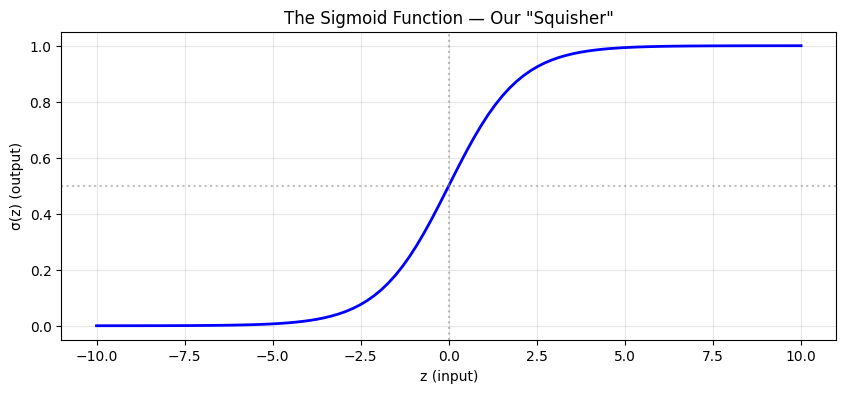

In [ ]:
import torch
import matplotlib.pyplot as plt

# Visualize sigmoid
z = torch.linspace(-10, 10, 100)
sigmoid = 1 / (1 + torch.exp(-z))

plt.figure(figsize=(10, 4))
plt.plot(z, sigmoid, 'b-', linewidth=2)
plt.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
plt.axvline(x=0, color='gray', linestyle=':', alpha=0.5)
plt.xlabel('z (input)')
plt.ylabel('σ(z) (output)')
plt.title('The Sigmoid Function — Our "Squisher"')
plt.grid(True, alpha=0.3)
plt.show()

---
## 5. Geometric Interpretation

Logistic regression finds a **hyperplane** (line in 2D) that separates classes.

> 🚪 **The Bouncer at the Door Analogy:**
> 
> The decision boundary is the **door** of a nightclub.
> - Far on VIP side → 100% confident they're getting in
> - Far on rejected side → 100% confident they're NOT getting in
> - Standing AT the door → 50/50, could go either way
> 
> **Distance from boundary = Confidence**

### What z = 0 Means

```
        CHURN SIDE (z > 0)
             |   😟 z = +5 → ŷ = 0.99
             |
=============|============  ← THE DOOR (z = 0 → ŷ = 0.5)
             |
             |   😊 z = -5 → ŷ = 0.01
        STAY SIDE (z < 0)
```

- \(z = 0\) is the equation of the decision boundary
- \(\hat{y} = 0.5\) means maximum uncertainty

---
## 6. Log-Loss — Measuring Wrongness

### The Cliff Edge Story

> 🏔️ **The Cliff Edge Analogy:**
> 
> Position 1 = safe ground 🏠, Position 0 = cliff edge 💀
> 
> **"Log stays calm near 1, screams near 0"**
> 
> - Standing at 0.95 → relaxing at home, tiny penalty
> - Standing at 0.10 → toes hanging off the edge, HUGE penalty!

### The Formulas

**When actual = 1:** Use \(-\log(\hat{y})\)
- Prediction near 1 → calm (small penalty)
- Prediction near 0 → screaming (huge penalty)

**When actual = 0:** Use \(-\log(1-\hat{y})\)
- Prediction near 0 → calm (small penalty)
- Prediction near 1 → screaming (huge penalty)

### Combined Formula (The Two Light Switches)

> 💡 **The Light Switch Analogy:**
> 
> - Lamp A = \(-\log(\hat{y})\)
> - Lamp B = \(-\log(1-\hat{y})\)
> - \(y\) is the switch: only ONE lamp is ever on!

\[
\text{Loss} = -\left[ y \cdot \log(\hat{y}) + (1-y) \cdot \log(1-\hat{y}) \right]
\]

| Actual \(y\) | Lamp A | Lamp B | Active Loss |
|:--:|:--:|:--:|:--|
| 1 | ON | OFF | \(-\log(\hat{y})\) |
| 0 | OFF | ON | \(-\log(1-\hat{y})\) |

In [ ]:
# Log Loss Implementation
def log_loss(y_actual, y_pred):
    eps = 1e-7  # avoid log(0)
    return -(y_actual * torch.log(y_pred + eps) + (1 - y_actual) * torch.log(1 - y_pred + eps))

# Test scenarios
print("When actual = 1:")
print(f"  Predict 0.99 → Loss = {log_loss(1, torch.tensor(0.99)):.4f}")
print(f"  Predict 0.10 → Loss = {log_loss(1, torch.tensor(0.10)):.4f}")

print("\nWhen actual = 0:")
print(f"  Predict 0.10 → Loss = {log_loss(0, torch.tensor(0.10)):.4f}")
print(f"  Predict 0.90 → Loss = {log_loss(0, torch.tensor(0.90)):.4f}")

When actual = 1:
  Predict 0.99 → Loss = 0.0101
  Predict 0.10 → Loss = 2.3026

When actual = 0:
  Predict 0.10 → Loss = 0.1054
  Predict 0.90 → Loss = 2.3026


---
## 7. Likelihood vs Probability

> 🍪 **The Cookie Jar Story:**
> 
> - Jar A: 90 chocolate, 10 vanilla
> - Jar B: 10 chocolate, 90 vanilla
> 
> **Probability:** "Given Jar A, what's the chance of picking chocolate?" (90%)
> 
> **Likelihood:** Friend picks chocolate → "Which jar was it probably from?" (Jar A!)

| | What's fixed? | What's unknown? | Question |
|:--|:--|:--|:--|
| **Probability** | The model | The data | "Given this model, what data might I see?" |
| **Likelihood** | The data | The model | "Given this data, what model fits best?" |

**Maximum Likelihood Estimation (MLE):** Find weights that make observed data most probable.

---
## 8. Why Not MSE?

> 📢 **The Screaming Guide Story:**
> 
> You're a blind hiker in fog. A guide shouts directions.
> 
> - **Log Loss Guide:** Far from village → **SCREAMS** "GO THAT WAY!!!"
> - **MSE Guide:** Far from village → speaks calmly "maybe go that way..."
> 
> Even when completely lost, the MSE guide barely raises their voice!

### The Math (The Magic)

| Loss | Gradient | When ŷ = 0.01 (very wrong) |
|:--|:--|:--|
| MSE | \(2(\hat{y} - y)\) | -1.98 (calm) |
| Log Loss | \(-\frac{1}{\hat{y}}\) | -100 (screaming!) |

**The key:** \(\frac{1}{\hat{y}}\) — smaller prediction → bigger gradient → louder guide!

### Convex vs Non-Convex

- **Log-loss + Sigmoid** = Convex (one valley) ✓
- **MSE + Sigmoid** = Non-convex (multiple valleys) ✗

With MSE, the hiker might get stuck in a crater thinking it's the valley!

---
## 9. Gradient Descent — Finding the Best Weights

> 🏔️ **The Blind Hiker on a Mountain:**
> 
> 1. Start at random position (random weights)
> 2. Feel the slope (calculate gradient)
> 3. Step downhill (update weights)
> 4. Repeat until you reach the valley (minimum loss)

### The Update Rule

\[
w_{\text{new}} = w_{\text{old}} - \text{learning\_rate} \times \text{gradient}
\]

### Learning Rate Trade-off

| Learning Rate | Behavior |
|:--|:--|
| Too big | Bounces around, overshoots the valley |
| Too small | Converges but takes forever |
| Just right | Smooth descent, reaches valley efficiently |

---
## 10. Complete Implementation

In [ ]:
import torch
import matplotlib.pyplot as plt

# Create fake customer data
torch.manual_seed(42)
n = 100
stayed_charge = torch.randn(n//2) * 20 + 30
stayed_calls = torch.randn(n//2) * 1 + 1
churned_charge = torch.randn(n//2) * 20 + 60
churned_calls = torch.randn(n//2) * 1 + 4

# Combine into X and y
X_stayed = torch.stack([stayed_charge, stayed_calls], dim=1)
X_churned = torch.stack([churned_charge, churned_calls], dim=1)
X = torch.cat([X_stayed, X_churned], dim=0)
y = torch.cat([torch.zeros(50), torch.ones(50)])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: torch.Size([100, 2])
y shape: torch.Size([100])


In [ ]:
# Training Loop
w = torch.randn(2, requires_grad=True)
b = torch.randn(1, requires_grad=True)
learning_rate = 0.005
eps = 1e-7

for step in range(1000):
    # 1. Forward pass
    z = X @ w + b
    y_pred = torch.sigmoid(z)
    
    # 2. Calculate loss
    loss = -torch.mean(y * torch.log(y_pred + eps) + (1 - y) * torch.log(1 - y_pred + eps))
    
    # 3. Backward pass
    loss.backward()
    
    # 4. Update weights
    with torch.no_grad():
        w.data -= learning_rate * w.grad
        b.data -= learning_rate * b.grad
        w.grad.zero_()
        b.grad.zero_()
    
    if step % 100 == 0:
        print(f"Step {step}: Loss = {loss.item():.4f}")

Step 0: Loss = 8.1505
Step 100: Loss = 8.0899
Step 200: Loss = 8.0255
Step 300: Loss = 1.0870
Step 400: Loss = 1.0464
Step 500: Loss = 1.0089
Step 600: Loss = 0.9735
Step 700: Loss = 0.9395
Step 800: Loss = 0.9069
Step 900: Loss = 0.8759


In [ ]:
# Check accuracy
y_pred_final = torch.sigmoid(X @ w + b)
predictions = (y_pred_final > 0.5).float()
accuracy = (predictions.squeeze() == y).float().mean()
print(f"Accuracy: {accuracy.item()*100:.1f}%")
print(f"Learned weights: w = {w.data}, b = {b.data}")

Accuracy: 49.0%
Learned weights: w = tensor([-0.0717,  0.7376]), b = tensor([1.2532])


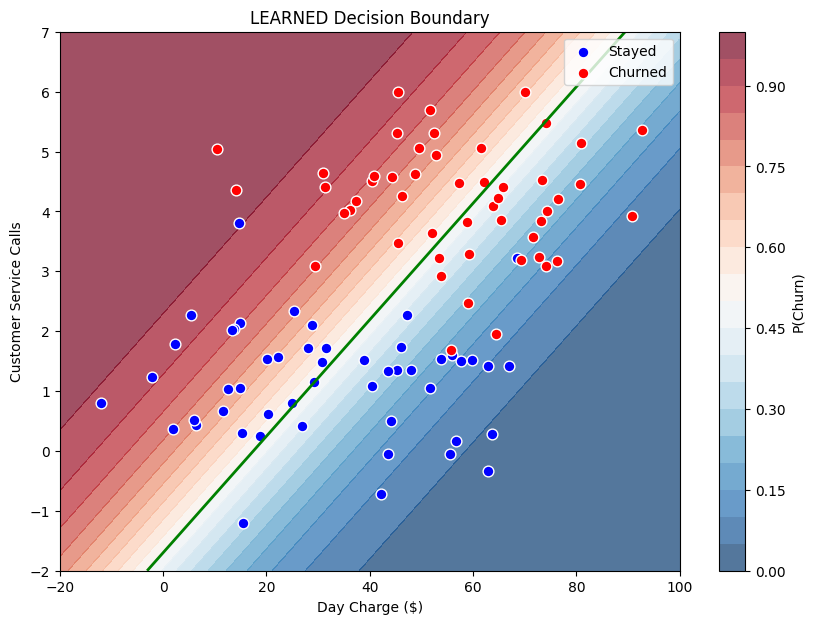

In [ ]:
# Visualize learned decision boundary
x_range = torch.linspace(-20, 100, 200)
y_range = torch.linspace(-2, 7, 200)
xx, yy = torch.meshgrid(x_range, y_range, indexing='xy')

grid_input = torch.stack([xx.flatten(), yy.flatten()], dim=1)
with torch.no_grad():
    z_grid = grid_input @ w + b
    probs = torch.sigmoid(z_grid).reshape(200, 200)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, probs, levels=20, cmap='RdBu_r', alpha=0.7)
plt.colorbar(label='P(Churn)')
plt.scatter(X[:50, 0], X[:50, 1], c='blue', edgecolor='white', s=60, label='Stayed')
plt.scatter(X[50:, 0], X[50:, 1], c='red', edgecolor='white', s=60, label='Churned')
plt.contour(xx, yy, probs, levels=[0.5], colors='green', linewidths=2)
plt.xlabel('Day Charge ($)')
plt.ylabel('Customer Service Calls')
plt.title('LEARNED Decision Boundary')
plt.legend()
plt.show()

---
## 11. Regularization

Prevents **overfitting** — when the model memorizes training data but fails on new data.

**L2 Regularization (Ridge):**
\[
\text{Loss} = \text{Log Loss} + \lambda \sum w_i^2
\]

**L1 Regularization (Lasso):**
\[
\text{Loss} = \text{Log Loss} + \lambda \sum |w_i|
\]

Same concept as linear regression — just added to log loss instead of MSE.

---
## 12. Interpreting Coefficients

**In Linear Regression:** "Increase X by 1 → Y increases by w"

**In Logistic Regression:** Coefficients represent change in **log-odds**, not probability!

\[
\log\left(\frac{P(\text{churn})}{P(\text{stay})}\right) = w_1 \cdot x_1 + w_2 \cdot x_2 + b
\]

**Example:** If \(w_2 = 0.74\):
- Log-odds interpretation: "Each additional service call increases log-odds of churn by 0.74"
- Odds ratio: \(e^{0.74} \approx 2.1\) → "Each additional service call **doubles** the odds of churning"

---
## 13. Quick Reference

### Key Formulas

| Component | Formula |
|:--|:--|
| Sigmoid | \(\sigma(z) = \frac{1}{1 + e^{-z}}\) |
| Linear part | \(z = w^T x + b\) |
| Log Loss | \(-\left[ y \log(\hat{y}) + (1-y) \log(1-\hat{y}) \right]\) |
| Gradient Update | \(w_{new} = w_{old} - \alpha \cdot \nabla L\) |

### Sticky Analogies Summary

| Concept | Analogy |
|:--|:--|
| Gradient Descent | Blind hiker feeling slope to find valley |
| Step function problem | Hiker on flat ground, can't feel direction |
| Sigmoid output | Bouncer confidence — distance from door |
| Log loss penalty | Cliff edge — calm near 1, screams near 0 |
| Log loss formula | Two light switches — only one ON at a time |
| Likelihood vs Probability | Cookie jar — know data, guess the jar |
| MSE vs Log Loss gradients | Calm guide vs screaming guide |
| Convex vs Non-convex | Single valley vs mountain with craters |
| Variance/Std Dev | Village well — measuring walking distance |

### Standard Deviation Reminder (Village Well Story)

| Step | Why? |
|:--|:--|
| Subtract mean | Find distance from center |
| Square | Stop negative and positive from cancelling |
| Average | Get typical squared-distance (**variance**) |
| Square root | Convert back to real-world units (**std dev**) |

> **"Variance is for math; standard deviation is for humans."**

### Training Loop Checklist

```python
for step in range(n_steps):
    # 1. Forward pass
    z = X @ w + b
    y_pred = torch.sigmoid(z)
    
    # 2. Calculate loss
    loss = log_loss(y, y_pred)
    
    # 3. Backward pass
    loss.backward()
    
    # 4. Update weights
    with torch.no_grad():
        w.data -= lr * w.grad
        b.data -= lr * b.grad
        w.grad.zero_()
        b.grad.zero_()
```

## Quiz Questions — Test Your Understanding

### Question 1 (Easy)
**Q:** Why can't we use a step function for classification?
> **A:** Can't take gradient → can't learn → can't update weights.

### Question 2 (Easy-Medium)
**Q:** Sigmoid outputs what range? What does it represent?
> **A:** Range (0, 1). Represents probability of belonging to class 1.

### Question 3 (Medium)
**Q:** Why use \(-\log(\hat{y})\) instead of \((1 - \hat{y})\)?
> **A:** Cliff edge story! Log explodes near 0 → penalizes confident wrong predictions severely.

### Question 4 (Medium-Tricky) ⚠️
**Q:** What if y = 0.5 in the log loss formula?
> **A:** Trick question! \(y\) is the actual label — always 0 or 1, never 0.5.

### Question 5 (Tricky)
**Q:** Why was w₁ (charge) ≈ 0 but w₂ (calls) = 0.74?
> **A:** Gradient descent learned that service calls is a stronger predictor than charge from the data.

### Question 6 (Tricky) ⚠️
**Q:** If ŷ = 0.5, what is z?
> **A:** z = 0. The point is exactly on the decision boundary (the door). sigmoid(0) = 0.5

In [ ]:
#| hide

import subprocess
from pathlib import Path
from dialoghelper import curr_dialog

def deploy_notebook():
    nb_name = Path(curr_dialog()['name']).name + '.ipynb'
    src = f'/app/data/{curr_dialog()["name"]}.ipynb'
    dst = '/app/data/publish/portfolio/static/'
    print(nb_name)
    
    # Copy notebook to static folder
    subprocess.run(['cp', src, dst])
    
    # Deploy with plash
    subprocess.run(['plash_deploy'], cwd='/app/data/publish/portfolio')

In [ ]:
#| hide
deploy_notebook()